In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 Electricity Consumption Anomaly Detection (Unsupervised)
This project demonstrates residual-based anomaly detection under real constraints
This project detects abnormal electricity usage patterns using
forecast residuals and statistical diagnostics, without labeled anomalies.

 1. Problem Statement
Electricity consumption data often lacks labeled anomalies.
The goal is to detect abnormal behavior (e.g., theft, meter faults,
or sustained behavioral changes) while avoiding false alarms caused by normal daily or seasonal variation.

In [43]:
# Data Loading and Preprocessing
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values='?',
    parse_dates={'Datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False)
df = df.set_index('Datetime').sort_index()
df_minute = df.copy()
# Resample to hourly
df_hourly = df_minute.resample('H').mean()


C:\Users\ayush\AppData\Local\Temp\ipykernel_26852\2050939269.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\ayush\AppData\Local\Temp\ipykernel_26852\2050939269.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\ayush\AppData\Local\Temp\ipykernel_26852\2050939269.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(
C:\Users\ayush\AppData\Local\Temp\ipykernel_26852\2050939269.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version,

In [44]:
#The data is aggregated to hourly resolution to reduce noise and make consumption patterns easier to model.
print(df_hourly.head())
print(df_hourly.info())

                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-

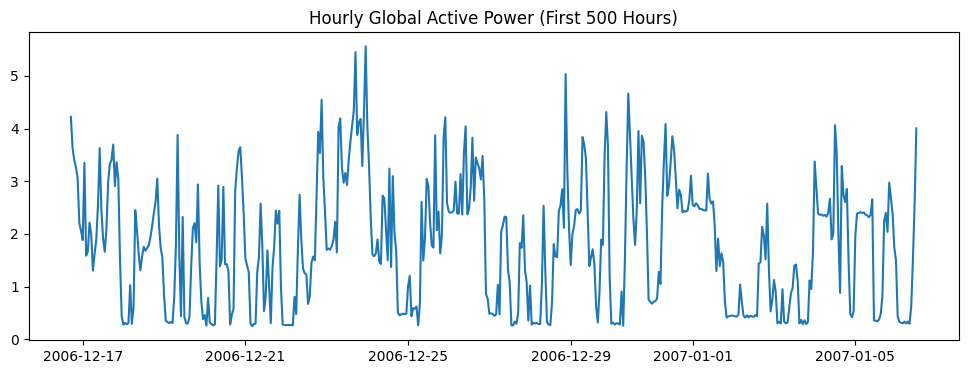

In [45]:
plt.figure(figsize=(12, 4))
plt.plot(df_hourly.index[:500], df_hourly['Global_active_power'][:500])
plt.title("Hourly Global Active Power (First 500 Hours)")
plt.show()
#Just to have a look at the data we plot some of it

Instead of predicting anomalies directly, a baseline forecast
is used to model normal consumption behavior.
Anomalies are expected to appear as deviations from this baseline.

In [47]:
#here we do the baseline stuff
df_model = df_hourly.copy()
df_model['y_true'] = df_model['Global_active_power']
df_model['y_pred_baseline'] = df_model['Global_active_power'].shift(1)
# Drop first row
df_model = df_model.dropna()


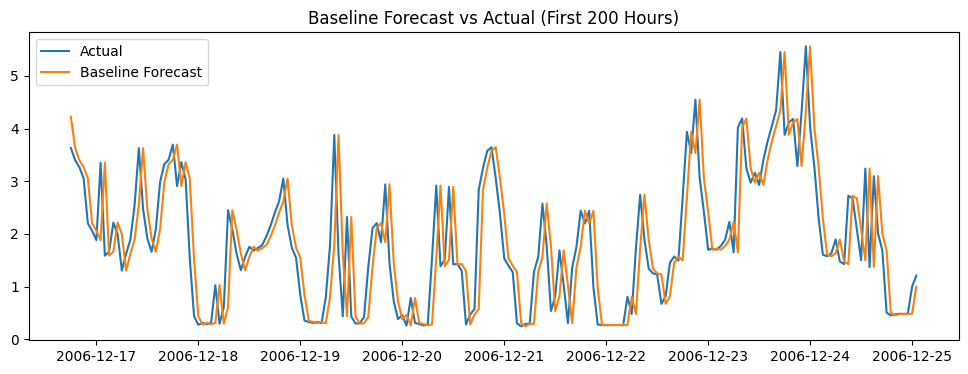

In [48]:
plt.figure(figsize=(12, 4))
plt.plot(df_model.index[:200], df_model['y_true'][:200], label='Actual')
plt.plot(df_model.index[:200], df_model['y_pred_baseline'][:200], label='Baseline Forecast')
plt.legend()
plt.title("Baseline Forecast vs Actual (First 200 Hours)")
plt.show()


In [14]:
#Residuals from baseline
df_model['residual_baseline'] = (
    df_model['y_true'] - df_model['y_pred_baseline'])

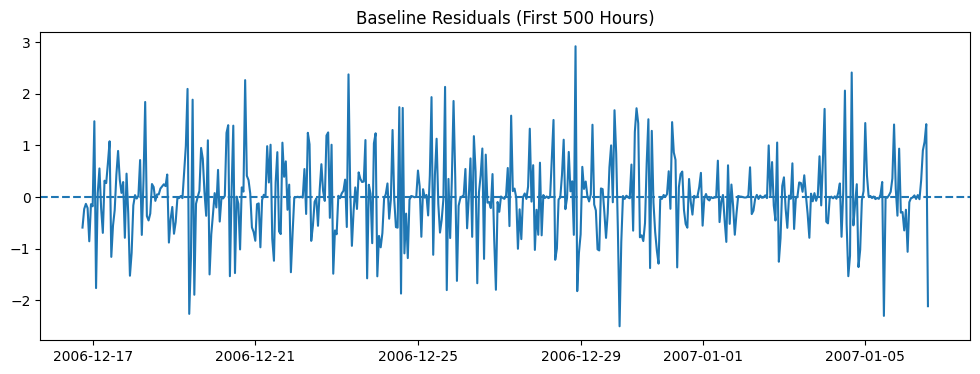

In [15]:
#RESIDUAL PLOT
plt.figure(figsize=(12, 4))
plt.plot(df_model.index[:500], df_model['residual_baseline'][:500])
plt.axhline(0, linestyle='--')
plt.title("Baseline Residuals (First 500 Hours)")
plt.show()

In [16]:
residuals = df_model['y_true'] - df_model['y_pred_baseline']

 Residual Diagnostics

Residuals represent the difference between actual consumption and the expected baseline behavior.
Before detecting anomalies, residuals must behave like noise:
No trend
No strong autocorrelation
Stable variance
If these conditions are violated, anomaly detection would be unreliable.


In [22]:
from statsmodels.tsa.stattools import acf
import numpy as np
# Compute autocorrelation up to 48 hours
acf_vals = acf(residuals.dropna(), nlags=48)
# Print first few values
for lag, val in enumerate(acf_vals[:10]):
    print(f"Lag {lag}: {val:.3f}")


Lag 0: 1.000
Lag 1: -0.067
Lag 2: -0.121
Lag 3: -0.075
Lag 4: -0.086
Lag 5: -0.067
Lag 6: -0.043
Lag 7: -0.069
Lag 8: -0.069
Lag 9: -0.042


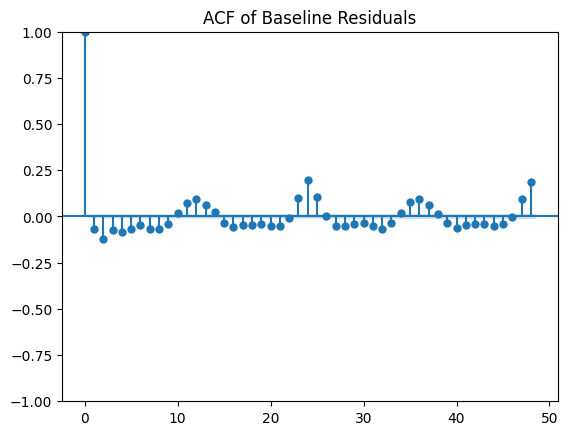

In [23]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_model['residual_baseline'], lags=48)
plt.title("ACF of Baseline Residuals")
plt.show()


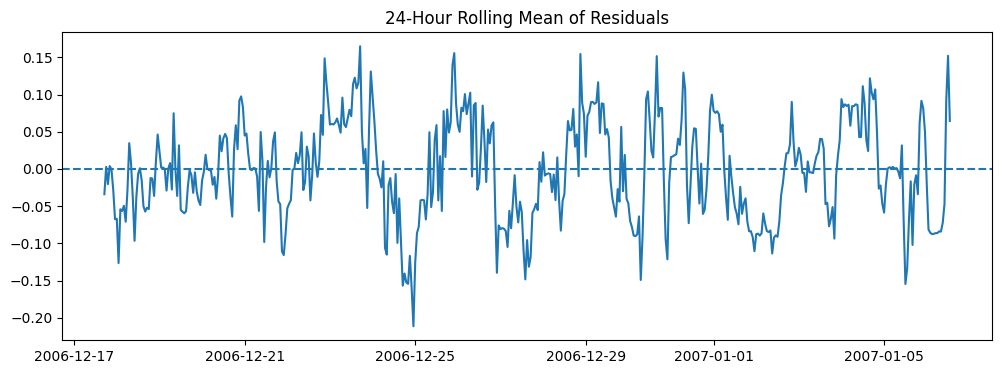

In [24]:
df_model['residual_rolling_mean'] = (
    df_model['residual_baseline']
    .rolling(window=24)
    .mean())
plt.figure(figsize=(12,4))
plt.plot(df_model.index[:500], df_model['residual_rolling_mean'][:500])
plt.axhline(0, linestyle='--')
plt.title("24-Hour Rolling Mean of Residuals")
plt.show()

Rolling mean oscillates around zero with std ~0.15.
No sustained bias detected → Forecasts unbiased over daily cycles.

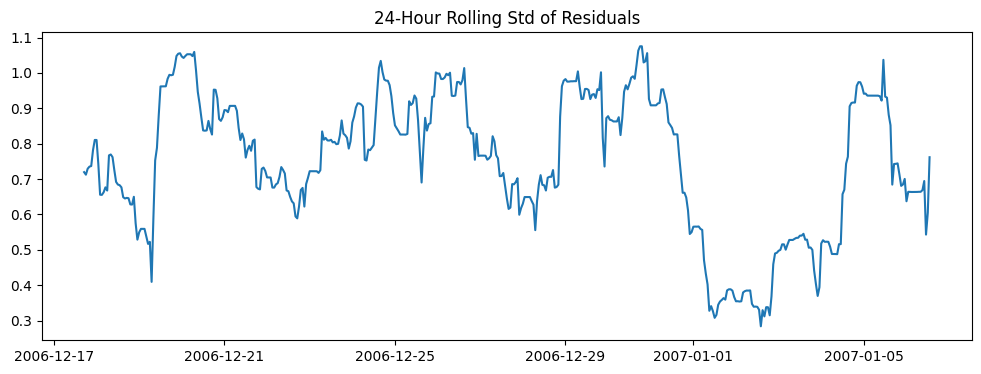

In [26]:
df_model['residual_rolling_std'] = (
    df_model['residual_baseline']
    .rolling(window=24)
    .std())
plt.figure(figsize=(12,4))
plt.plot(df_model.index[:500], df_model['residual_rolling_std'][:500])
plt.title("24-Hour Rolling Std of Residuals")
plt.show()

RESIDUAL DIAGNOSTICS SUMMARY:
Mean ≈ 0: Unbiased forecasts
ACF lags 1-24 < 0.1: No autocorrelation (patterns captured)
24hr rolling std stable ~0.8: Homoscedastic residuals
Rolling mean fluctuations < 0.2: No persistent bias
All these were the plots for residual diagnostics 
The diagnostics show that residuals are centered around zero,
have low autocorrelation, and stable variance,
indicating that anomaly detection is statistically valid.


In [27]:
df_model.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,y_true,y_pred_baseline,residual_baseline,residual_rolling_mean,residual_rolling_std
Datetime,,,,,,,,,,,,
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.632200,4.222889,-0.590689,NaN,NaN
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.400233,3.632200,-0.231967,NaN,NaN
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.268567,3.400233,-0.131667,NaN,NaN
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,3.056467,3.268567,-0.212100,NaN,NaN
2006-12-16 22:00:00,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333,2.200133,3.056467,-0.856333,NaN,NaN


Anomaly Detection Logic

A single spike is not considered an anomaly.
True anomalies must be:
Statistically large and Persistent over time

Residuals are standardized using a z-score.
Only residuals with |z| > 2 are considered unusually large.
To avoid false alarms, anomalies are flagged only if large residuals persist for multiple consecutive hours.


In [28]:
res_mean = df_model['residual_baseline'].mean()
res_std  = df_model['residual_baseline'].std()

df_model['residual_z'] = (
    (df_model['residual_baseline'] - res_mean) / res_std)

In [29]:
df_model['large_error'] = (
    df_model['residual_z'].abs() > 2)
df_model['error_persistence'] = (
    df_model['large_error']
    .astype(int)
    .groupby(
        (df_model['large_error'] != df_model['large_error'].shift()).cumsum()
    ).cumsum())

In [30]:
df_model['anomaly'] = (
    (df_model['large_error']) &
    (df_model['error_persistence'] >= 6))

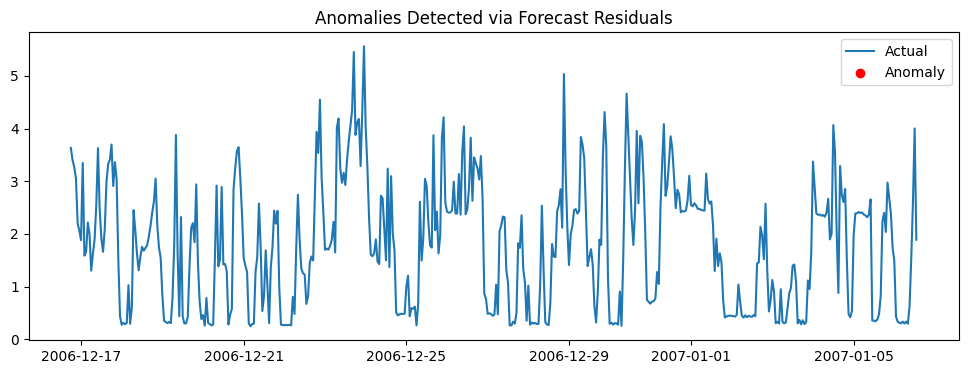

In [31]:
plt.figure(figsize=(12,4))
plt.plot(df_model.index[:500], df_model['y_true'][:500], label='Actual')
plt.scatter(
    df_model.index[:500][df_model['anomaly'][:500]],
    df_model['y_true'][:500][df_model['anomaly'][:500]],
    color='red',
    label='Anomaly'
)
plt.legend()
plt.title("Anomalies Detected via Forecast Residuals")
plt.show()


In the analyzed period, no sustained anomalies were detected.
This indicates stable household consumption behavior.
The absence of anomalies is a valid and meaningful result.


 Anomaly Severity and Persistence Scoring
Not all abnormal behavior is equally important.

This step assigns a continuous anomaly score that combines:

Severity – how large the deviation is from normal behavior

Persistence – how long the deviation lasts

This allows ranking events instead of using a hard yes/no anomaly label.

In [33]:
df_model['severity_score'] = df_model['residual_z'].abs()
df_model['anomaly_score'] = (
    df_model['severity_score'] *
    np.log1p(df_model['error_persistence']))

#Initially, with strict thresholds, no anomalies were detected — which indicated a stable system.To better understand subtle deviations,
#I transitioned from binary rules to a continuous anomaly score combining residual severity and temporal persistence.

 Severity Component

Severity is defined as the absolute z-score of the residual.

A larger absolute z-score means the observed consumption deviates
more strongly from expected behavior.
Both unusually high and unusually low consumption are treated equally.


Why use log(persistence)?

Persistence should increase anomaly importance,
but not dominate severity completely.

Using log here
- Gives zero weight when persistence = 0
- Grows slowly for long durations
- Prevents very long events from overpowering the score

This reflects real systems, where a 10-hour anomaly
is not 10× more severe than a 1-hour anomaly.

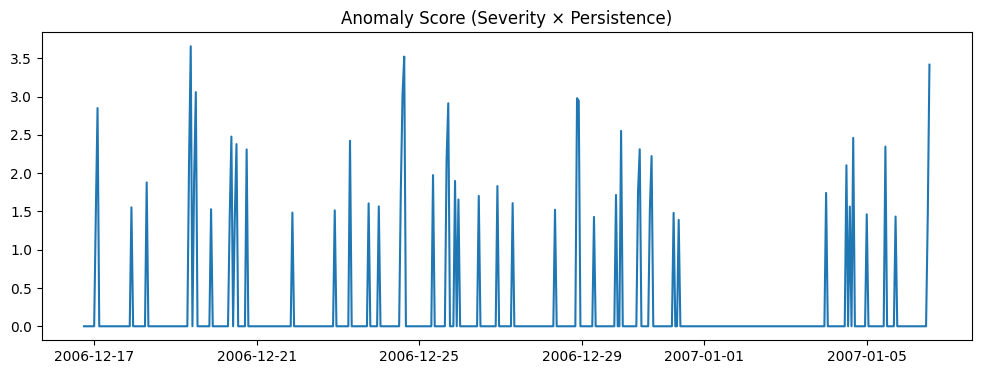

In [34]:
plt.figure(figsize=(12,4))
plt.plot(df_model.index[:500], df_model['anomaly_score'][:500])
plt.title("Anomaly Score (Severity × Persistence)")
plt.show()


 Interpretation

The anomaly score is high only when:
- Residuals are statistically large, and
- The abnormal behavior persists over time

Short-lived spikes receive low scores,
while sustained deviations are prioritized for investigation.


Limitations
- No labeled ground truth anomalies
- Thresholds are heuristic and domain-dependent
- Single-customer dataset
- No external features such as weather or holidays
